# Homework Buổi 2 - Xác suất thống kê cho AI

Họ tên: Nguyễn Huỳnh Nam Quốc  
MSSV: 2453089  
GitHub: namquoc2108-bot  

Em sử dụng dataset Iris để làm bài tập về thống kê mô tả, phân phối xác suất, tương quan và định lý Bayes.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)

df = iris.frame.copy()
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

df = df.rename(columns={
    "sepal length (cm)": "sepal_length",
    "sepal width (cm)": "sepal_width",
    "petal length (cm)": "petal_length",
    "petal width (cm)": "petal_width"
})

df = df.drop(columns=["target"])

numeric_cols = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

display(df.head())
print("Shape:", df.shape)
print("\nKiểu dữ liệu:")
print(df.dtypes)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Shape: (150, 5)

Kiểu dữ liệu:
sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object


Dataset Iris có 150 dòng và 5 cột. Trong đó có 4 biến số đo kích thước hoa và 1 cột species cho biết loài hoa. Đây là dataset phù hợp vì có đủ biến số để tính thống kê, vẽ phân phối và phân tích tương quan.

# Thống kê mô tả & đặc trưng

Tính mean, median, mode, var, std, min, max, Q1, Q3, IQR

In [16]:
stats = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    
    stats[col] = {
        "mean": df[col].mean(),
        "median": df[col].median(),
        "mode": df[col].mode().iloc[0],
        "var": df[col].var(),
        "std": df[col].std(),
        "min": df[col].min(),
        "max": df[col].max(),
        "Q1": q1,
        "Q3": q3,
        "IQR": q3 - q1
    }

stats_df = pd.DataFrame(stats).T
display(stats_df)

,mean,median,mode,var,std,min,max,Q1,Q3,IQR
sepal_length,5.843333,5.80,5.0,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3
sepal_width,3.057333,3.00,3.0,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5
petal_length,3.758000,4.35,1.4,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5
petal_width,1.199333,1.30,0.2,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5


Groupby theo species

In [17]:
group_stats = df.groupby("species", observed=True)[numeric_cols].agg(["mean", "std"])
display(group_stats)

group_means = df.groupby("species", observed=True)[numeric_cols].mean()
display(group_means)

mean_range = group_means.max() - group_means.min()
print("Độ chênh lệch mean giữa các loài:")
print(mean_range.sort_values(ascending=False))

sepal_length           sepal_width           petal_length  \
                   mean       std        mean       std         mean   
species                                                                
setosa            5.006  0.352490       3.428  0.379064        1.462   
versicolor        5.936  0.516171       2.770  0.313798        4.260   
virginica         6.588  0.635880       2.974  0.322497        5.552   

                     petal_width            
                 std        mean       std  
species                                     
setosa      0.173664       0.246  0.105386  
versicolor  0.469911       1.326  0.197753  
virginica   0.551895       2.026  0.274650

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Độ chênh lệch mean giữa các loài:
petal_length    4.090
petal_width     1.780
sepal_length    1.582
sepal_width     0.658
dtype: float64


Nhận xét:

Khi so sánh mean theo từng loài, em thấy `petal_length` và `petal_width` khác biệt rõ nhất giữa các nhóm. Setosa có cánh hoa ngắn và hẹp hơn hẳn so với versicolor và virginica. Trong khi đó, các biến về sepal cũng có khác biệt nhưng không tách rõ bằng petal.

Điều này làm em thấy các đặc trưng liên quan đến cánh hoa có vẻ hữu ích hơn nếu dùng để phân loại loài hoa Iris.

# Phân phối xác suất

Histogram + KDE cho từng biến


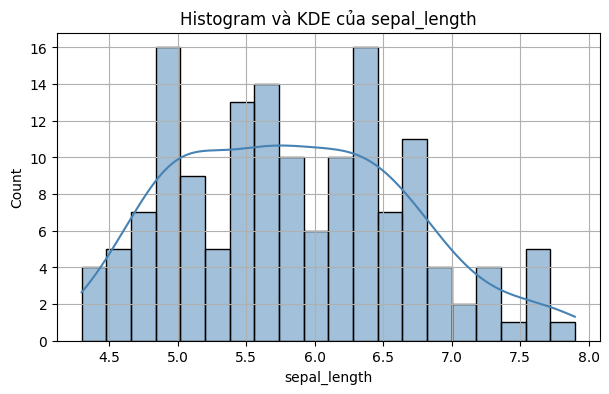

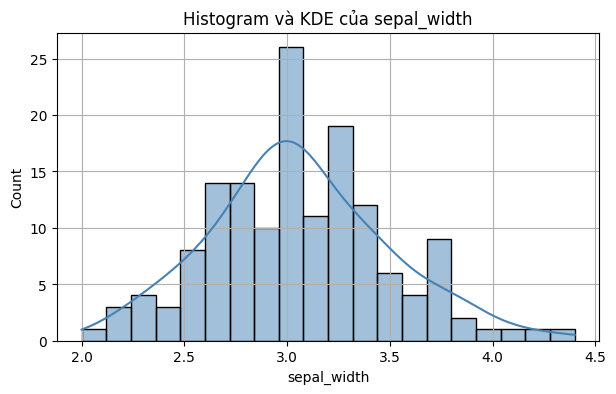

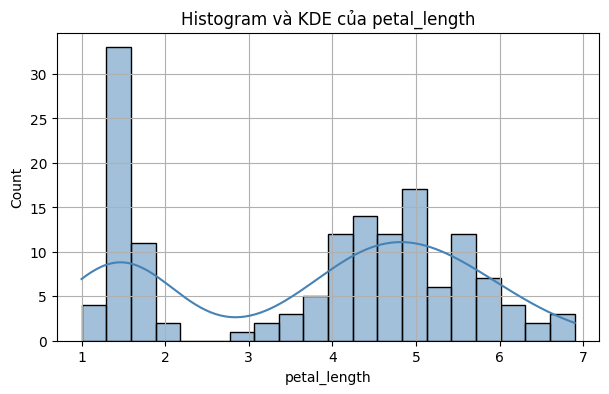

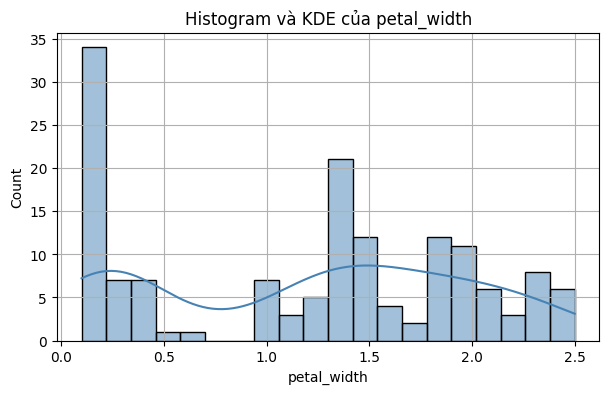

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(x=df[col], kde=True, bins=20, color="steelblue")
    plt.title(f"Histogram và KDE của {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

Nhận xét:

Các biến petal_length và petal_width có phân phối nhiều đỉnh khá rõ, vì dữ liệu gồm nhiều loài hoa khác nhau trộn lại. Setosa thường có petal nhỏ hơn nhiều nên tạo thành một cụm riêng. Các biến sepal nhìn mềm hơn nhưng vẫn không hoàn toàn giống phân phối chuẩn.

Boxplot theo species

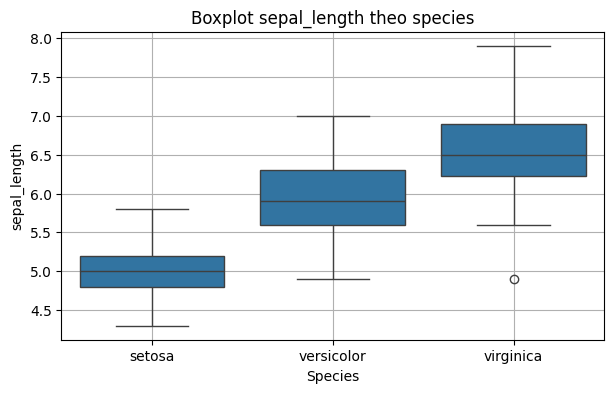

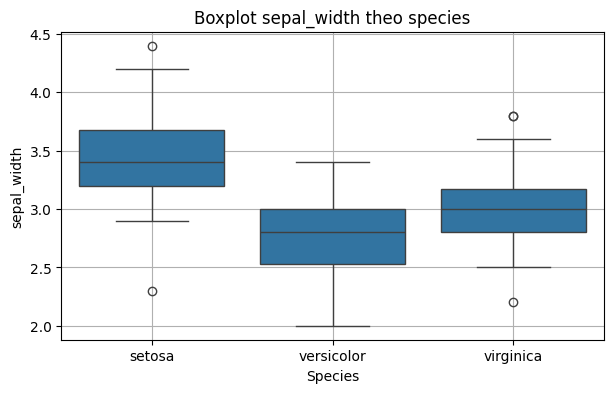

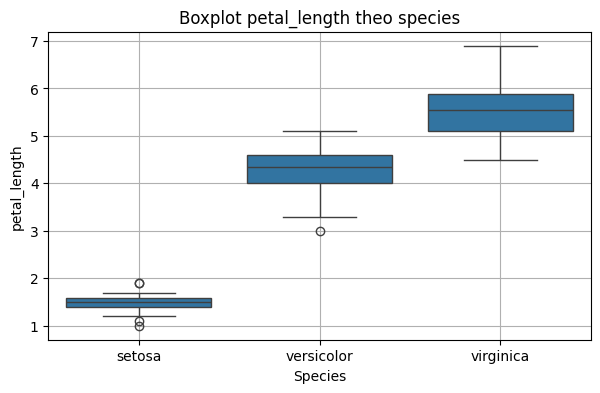

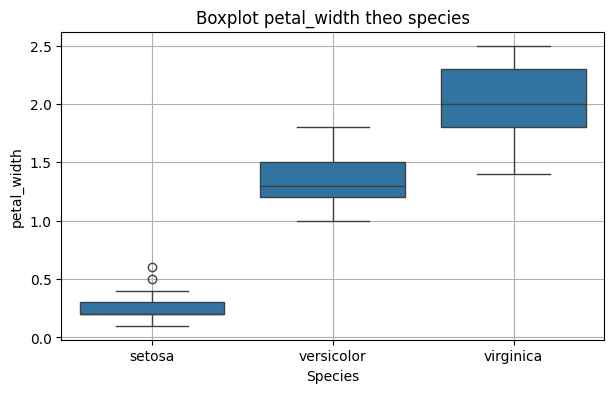

In [19]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=df, x="species", y=col)
    plt.title(f"Boxplot {col} theo species")
    plt.xlabel("Species")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

Nhận xét:

Boxplot cho thấy setosa tách khá rõ ở petal_length và petal_width. Versicolor và virginica có phần gần nhau hơn, nhưng virginica thường có petal lớn hơn. Nhìn biểu đồ này, em thấy petal_length và petal_width là hai đặc trưng phân biệt loài tốt hơn sepal_length và sepal_width.

Mô phỏng phân phối Normal

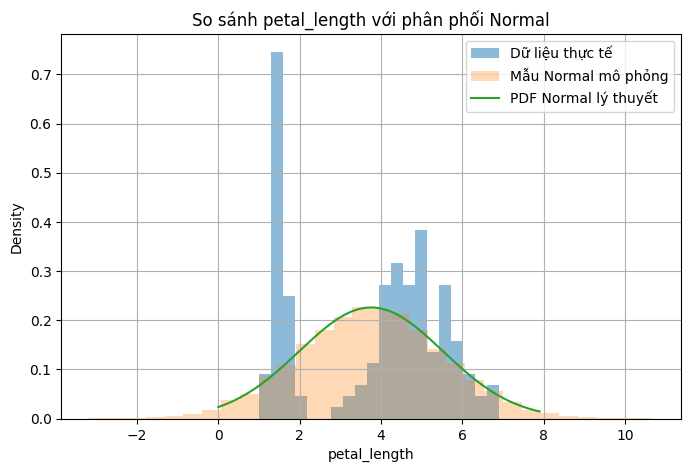

Mean: 3.758
Std: 1.7653


In [20]:
col = "petal_length"

mu = df[col].mean()
sigma = df[col].std()

np.random.seed(42)
normal_samples = np.random.normal(mu, sigma, size=10000)

x_values = np.linspace(df[col].min() - 1, df[col].max() + 1, 300)
pdf_values = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_values - mu) / sigma) ** 2
)

plt.figure(figsize=(8, 5))
plt.hist(df[col], bins=20, density=True, alpha=0.5, label="Dữ liệu thực tế")
plt.hist(normal_samples, bins=30, density=True, alpha=0.3, label="Mẫu Normal mô phỏng")
plt.plot(x_values, pdf_values, label="PDF Normal lý thuyết")
plt.title(f"So sánh {col} với phân phối Normal")
plt.xlabel(col)
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()

print("Mean:", round(mu, 4))
print("Std:", round(sigma, 4))

Nhận xét:

Dù em dùng mean và std của dữ liệu thật để tạo phân phối Normal, đường Normal vẫn không khớp hoàn toàn với petal_length. Lý do là dữ liệu Iris không đến từ một nhóm duy nhất, mà gồm 3 loài hoa khác nhau. Vì vậy phân phối thực tế có xu hướng nhiều cụm, đặc biệt setosa tách ra khá rõ. Điều này cho thấy không phải dữ liệu nào cũng có thể được mô tả tốt bằng một phân phối chuẩn đơn giản.

# Phân tích đa biến & tương quan

Covariance và Correlation

In [21]:
cov_matrix = df[numeric_cols].cov()
corr_matrix = df[numeric_cols].corr()

print("Covariance matrix:")
display(cov_matrix)

print("Correlation matrix:")
display(corr_matrix)

Covariance matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,0.685694,-0.042434,1.274315,0.516271
sepal_width,-0.042434,0.189979,-0.329656,-0.121639
petal_length,1.274315,-0.329656,3.116278,1.295609
petal_width,0.516271,-0.121639,1.295609,0.581006


Correlation matrix:


,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


Heatmap tương quan

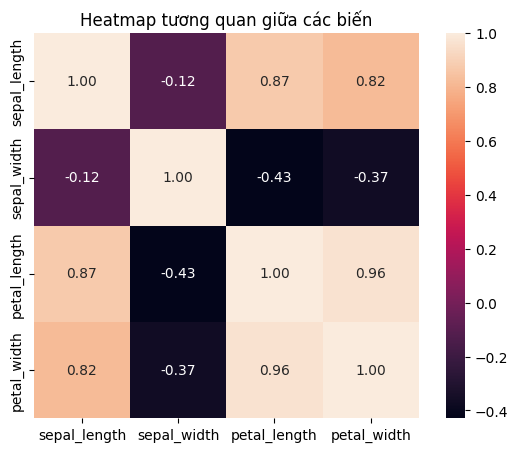

Cặp biến tương quan mạnh nhất: ('petal_length', 'petal_width')
Hệ số tương quan: 0.9629


In [22]:
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", square=True)
plt.title("Heatmap tương quan giữa các biến")
plt.show()

corr_abs = corr_matrix.abs().copy()
np.fill_diagonal(corr_abs.values, np.nan)

strongest_pair = corr_abs.unstack().sort_values(ascending=False).dropna().index[0]
strongest_value = corr_matrix.loc[strongest_pair[0], strongest_pair[1]]

print("Cặp biến tương quan mạnh nhất:", strongest_pair)
print("Hệ số tương quan:", round(strongest_value, 4))

Nhận xét:

Cặp biến tương quan mạnh nhất thường là petal_length và petal_width. Điều này khá dễ hiểu vì hoa có cánh dài thì thường cánh cũng rộng hơn. Hệ số tương quan cao cho thấy hai biến này chứa thông tin khá giống nhau.

Có dấu hiệu đa cộng tuyến giữa một số biến petal, vì chúng tương quan rất mạnh. Nếu sau này dùng mô hình tuyến tính, em cần chú ý vì các biến quá giống nhau có thể làm mô hình khó diễn giải hơn.

Pairplot

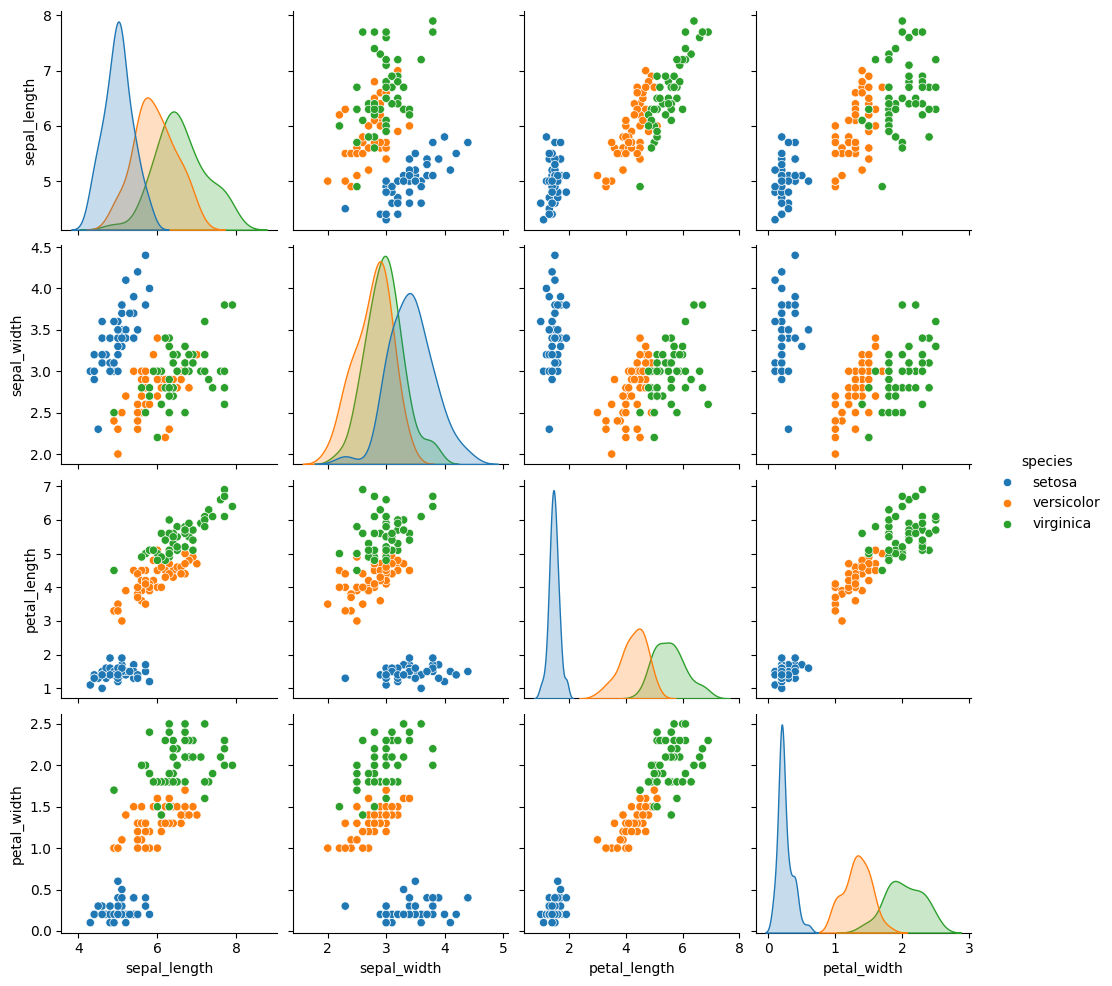

In [23]:
sns.pairplot(df, vars=numeric_cols, hue="species")
plt.show()

Nhận xét:

Pairplot cho thấy setosa tách ra rất rõ ở các biểu đồ có petal_length hoặc petal_width. Versicolor và virginica gần nhau hơn nên khó phân biệt hơn một chút. Nhìn tổng thể, các biến liên quan đến petal giúp chia nhóm tốt hơn các biến sepal.

# Xác suất & Định lý Bayes

Tính P(B | +)

In [24]:
P_B = 0.01
P_not_B = 1 - P_B

P_pos_given_B = 0.99
P_pos_given_not_B = 0.05

P_pos = P_pos_given_B * P_B + P_pos_given_not_B * P_not_B
P_B_given_pos = P_pos_given_B * P_B / P_pos

print("P(+) =", round(P_pos, 4))
print("P(B | +) =", round(P_B_given_pos, 4))
print("P(B | +) theo phần trăm =", round(P_B_given_pos * 100, 2), "%")

P(+) = 0.0594
P(B | +) = 0.1667
P(B | +) theo phần trăm = 16.67 %


Khảo sát khi P(B) thay đổi

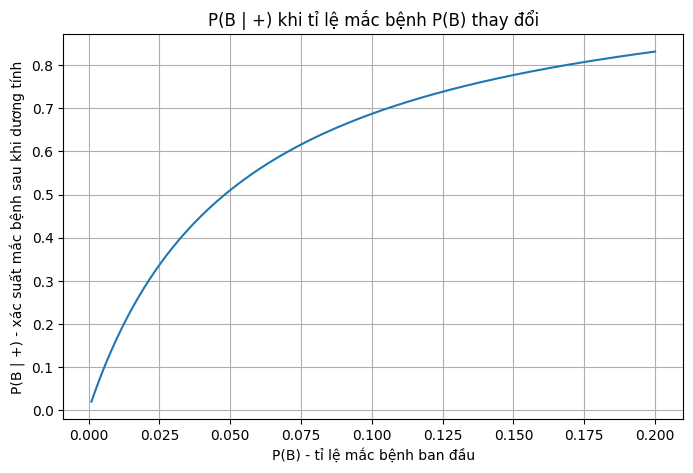

In [25]:
P_B_values = np.linspace(0.001, 0.2, 300)

P_pos_values = (
    P_pos_given_B * P_B_values
    + P_pos_given_not_B * (1 - P_B_values)
)

P_B_given_pos_values = P_pos_given_B * P_B_values / P_pos_values

plt.figure(figsize=(8, 5))
plt.plot(P_B_values, P_B_given_pos_values)
plt.title("P(B | +) khi tỉ lệ mắc bệnh P(B) thay đổi")
plt.xlabel("P(B) - tỉ lệ mắc bệnh ban đầu")
plt.ylabel("P(B | +) - xác suất mắc bệnh sau khi dương tính")
plt.grid(True)
plt.show()

Nhận xét:

Kết quả Bayes làm em hơi bất ngờ lúc đầu. Dù xét nghiệm có độ nhạy rất cao 0.99, nhưng khi bệnh hiếm với P(B) = 0.01 thì xác suất thật sự mắc bệnh sau khi dương tính chỉ khoảng 16.67%.

Lý do là trong dân số có rất nhiều người không mắc bệnh. Chỉ cần tỉ lệ dương tính giả là 0.05 thì số người không bệnh nhưng test dương tính vẫn có thể khá lớn. Vì vậy khi bệnh hiếm, một kết quả dương tính chưa chắc đồng nghĩa với việc người đó gần như chắc chắn mắc bệnh.

Khi P(B) tăng lên, P(B | +) cũng tăng theo. Điều này cho thấy xác suất ban đầu của bệnh đóng vai trò rất quan trọng trong việc diễn giải kết quả xét nghiệm.

## Bonus — Bộ lọc spam đơn giản bằng Naive Bayes

Ở phần bonus này, em tự tạo một bộ dữ liệu nhỏ gồm vài email mẫu.  
Mỗi email được gán nhãn:
- `1`: spam
- `0`: không spam

Sau đó em dùng ý tưởng Naive Bayes để tính xác suất một email mới có phải spam hay không dựa trên các từ khóa xuất hiện trong email.

In [26]:
import re
import numpy as np
import pandas as pd

# Dữ liệu nhỏ do em tự tạo
# label = 1: spam, label = 0: không spam
train_emails = [
    ("Bạn đã trúng thưởng lớn hãy click ngay để nhận quà", 1),
    ("Nhận khuyến mãi miễn phí hôm nay click vào link này", 1),
    ("Cơ hội kiếm tiền nhanh không cần kinh nghiệm", 1),
    ("Tài khoản của bạn cần xác nhận mật khẩu ngay", 1),
    ("Mua ngay hôm nay để nhận ưu đãi cực lớn", 1),
    
    ("Thầy nhắc lớp nộp bài tập trước tối nay", 0),
    ("Nhóm mình họp lúc 8 giờ để làm dự án", 0),
    ("Bạn gửi lại file báo cáo cho mình nhé", 0),
    ("Lịch học tuần này có thay đổi nhẹ", 0),
    ("Mình đã hoàn thành phần code của bài tập", 0)
]

# Một vài từ khóa đơn giản
keywords = [
    "trúng", "thưởng", "click", "nhận", "quà", "khuyến", "mãi",
    "miễn", "phí", "tiền", "nhanh", "mật", "khẩu", "ưu", "đãi",
    "lớp", "bài", "tập", "họp", "dự", "án", "file", "báo", "cáo", "lịch", "học"
]

def tokenize(text):
    return re.findall(r"\w+", text.lower())

def email_to_vector(email, keywords):
    words = set(tokenize(email))
    return np.array([1 if kw in words else 0 for kw in keywords])

X_train = np.array([email_to_vector(email, keywords) for email, label in train_emails])
y_train = np.array([label for email, label in train_emails])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (10, 26)
y_train shape: (10,)


In [27]:
def train_naive_bayes(X, y, alpha=1.0):
    """
    Huấn luyện Naive Bayes dạng Bernoulli.
    Mỗi từ khóa chỉ xét có xuất hiện hoặc không xuất hiện trong email.
    alpha dùng để làm Laplace smoothing, tránh xác suất bằng 0.
    """
    n_samples, n_features = X.shape
    
    spam_mask = y == 1
    ham_mask = y == 0
    
    P_spam = np.mean(spam_mask)
    P_ham = np.mean(ham_mask)
    
    X_spam = X[spam_mask]
    X_ham = X[ham_mask]
    
    # P(keyword xuất hiện | spam)
    P_word_given_spam = (X_spam.sum(axis=0) + alpha) / (X_spam.shape[0] + 2 * alpha)
    
    # P(keyword xuất hiện | không spam)
    P_word_given_ham = (X_ham.sum(axis=0) + alpha) / (X_ham.shape[0] + 2 * alpha)
    
    return P_spam, P_ham, P_word_given_spam, P_word_given_ham


P_spam, P_ham, P_word_given_spam, P_word_given_ham = train_naive_bayes(X_train, y_train)

print("P(spam) =", round(P_spam, 3))
print("P(không spam) =", round(P_ham, 3))

P(spam) = 0.5
P(không spam) = 0.5


In [28]:
def predict_spam_probability(email):
    x = email_to_vector(email, keywords)
    
    # Dùng log để tránh nhân nhiều xác suất nhỏ làm underflow
    log_spam = np.log(P_spam)
    log_ham = np.log(P_ham)
    
    for i, value in enumerate(x):
        if value == 1:
            log_spam += np.log(P_word_given_spam[i])
            log_ham += np.log(P_word_given_ham[i])
        else:
            log_spam += np.log(1 - P_word_given_spam[i])
            log_ham += np.log(1 - P_word_given_ham[i])
    
    # Đổi từ log-score về xác suất
    max_log = max(log_spam, log_ham)
    spam_score = np.exp(log_spam - max_log)
    ham_score = np.exp(log_ham - max_log)
    
    P_spam_given_email = spam_score / (spam_score + ham_score)
    
    return P_spam_given_email


test_emails = [
    "Bạn đã trúng thưởng hãy click để nhận quà miễn phí",
    "Nhóm mình họp để làm bài tập dự án tối nay",
    "Tài khoản của bạn cần xác nhận mật khẩu để nhận ưu đãi"
]

results = []

for email in test_emails:
    prob_spam = predict_spam_probability(email)
    label = "spam" if prob_spam >= 0.5 else "không spam"
    
    results.append({
        "email": email,
        "P(spam | email)": round(prob_spam, 4),
        "dự đoán": label
    })

results_df = pd.DataFrame(results)
display(results_df)

,email,P(spam | email),dự đoán
0,Bạn đã trúng thưởng hãy click để nhận quà miễn...,0.9992,spam
1,Nhóm mình họp để làm bài tập dự án tối nay,0.0009,không spam
2,Tài khoản của bạn cần xác nhận mật khẩu để nhậ...,0.9917,spam


Nhận xét:

Ở phần bonus này, em dùng Naive Bayes theo cách khá đơn giản: mỗi email được biểu diễn bằng việc có hoặc không có một số từ khóa. Những từ như "trúng", "thưởng", "click", "miễn", "phí", "mật khẩu" thường làm xác suất spam tăng lên. Ngược lại, các từ như "lớp", "bài tập", "họp", "dự án", "báo cáo" thường làm email giống nhóm không spam hơn.

Kết quả cho thấy email đầu tiên có nhiều từ khóa quảng cáo như "trúng thưởng", "click", "nhận quà", "miễn phí" nên xác suất spam cao. Email thứ hai nói về họp nhóm và bài tập nên được dự đoán là không spam. Email thứ ba hơi đáng nghi hơn vì có các từ như "tài khoản", "mật khẩu", "ưu đãi", nên mô hình có xu hướng xem là spam.

Qua phần này, em hiểu rõ hơn ý tưởng của Naive Bayes: mô hình không thật sự hiểu nội dung email như con người, mà dựa vào xác suất xuất hiện của các từ khóa trong từng nhóm. Cách làm này đơn giản nhưng khá dễ hiểu, và cũng cho thấy vì sao việc chọn từ khóa và dữ liệu huấn luyện ảnh hưởng rất nhiều đến kết quả.